In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [6]:
DATA_DIR = Path("../data/raw/eclipse")

ck = pd.read_csv(
    DATA_DIR / "single-version-ck-oo.csv",
    sep=";",
)

change = pd.read_csv(
    DATA_DIR / "change-metrics.csv",
    sep=";",
)

In [7]:
DATA_DIR = Path("../data/raw/eclipse")

ck = pd.read_csv(
    DATA_DIR / "single-version-ck-oo.csv",
    sep=";",
)

change = pd.read_csv(
    DATA_DIR / "change-metrics.csv",
    sep=";",
)

In [8]:
ck.head()

,classname,cbo,dit,fanIn,fanOut,lcom,noc,numberOfAttributes,numberOfAttributesInherited,numberOfLinesOfCode,...,numberOfPublicAttributes,numberOfPublicMethods,rfc,wmc,bugs,nonTrivialBugs,majorBugs,criticalBugs,highPriorityBugs,
0,org::eclipse::jdt::internal::core::search::ind...,9,2,1,9,15,0,1,8,122.0,...,1.0,5,34.0,20.0,0,0,0,0,0,
1,org::eclipse::jdt::internal::compiler::codegen...,1,1,1,0,0,0,2,0,4.0,...,2.0,1,1.0,1.0,0,0,0,0,0,
2,org::eclipse::jdt::internal::compiler::ast::AS...,114,1,102,18,190,6,131,249,484.0,...,3.0,19,156.0,176.0,1,0,0,0,0,
3,org::eclipse::jdt::internal::compiler::lookup:...,5,6,1,4,10,0,0,61,33.0,...,0.0,4,18.0,12.0,0,0,0,0,0,
4,org::eclipse::jdt::internal::eval::CodeSnippet...,23,2,1,22,820,0,7,416,673.0,...,7.0,1,174.0,115.0,0,0,0,0,0,


In [9]:
change.head()

,classname,numberOfVersionsUntil:,numberOfFixesUntil:,numberOfRefactoringsUntil:,numberOfAuthorsUntil:,linesAddedUntil:,maxLinesAddedUntil:,avgLinesAddedUntil:,linesRemovedUntil:,maxLinesRemovedUntil:,...,maxCodeChurnUntil:,avgCodeChurnUntil:,ageWithRespectTo:,weightedAgeWithRespectTo:,bugs,nonTrivialBugs,majorBugs,criticalBugs,highPriorityBugs,
0,org::eclipse::jdt::internal::core::search::ind...,65,4,0,8,608.0,158.0,9.35385,566.0,158.0,...,15.0,0.646154,350.571,63.0609,0,0,0,0,0,
1,org::eclipse::jdt::internal::compiler::codegen...,2,0,0,2,10.0,10.0,5.00000,0.0,0.0,...,10.0,5.000000,117.714,0.0000,0,0,0,0,0,
2,org::eclipse::jdt::internal::compiler::ast::AS...,120,10,0,12,1361.0,99.0,11.34170,768.0,77.0,...,66.0,4.941670,238.429,104.2040,1,0,0,0,0,
3,org::eclipse::jdt::internal::compiler::lookup:...,28,4,0,5,138.0,39.0,4.92857,123.0,39.0,...,23.0,0.535714,367.000,112.6780,0,0,0,0,0,
4,org::eclipse::jdt::internal::eval::CodeSnippet...,93,17,0,8,1870.0,684.0,20.10750,1881.0,692.0,...,18.0,-0.118280,367.000,54.9702,0,0,0,0,0,


In [10]:
print("CK:", ck.shape)
print("Change:", change.shape)

CK: (997, 24)
Change: (997, 22)


In [12]:
ck.columns.tolist()

['classname ',
 ' cbo ',
 ' dit ',
 ' fanIn ',
 ' fanOut ',
 ' lcom ',
 ' noc ',
 ' numberOfAttributes ',
 ' numberOfAttributesInherited ',
 ' numberOfLinesOfCode ',
 ' numberOfMethods ',
 ' numberOfMethodsInherited ',
 ' numberOfPrivateAttributes ',
 ' numberOfPrivateMethods ',
 ' numberOfPublicAttributes ',
 ' numberOfPublicMethods ',
 ' rfc ',
 ' wmc ',
 ' bugs ',
 ' nonTrivialBugs ',
 ' majorBugs ',
 ' criticalBugs ',
 ' highPriorityBugs ',
 ' ']

In [13]:
change.columns.tolist()

['classname ',
 ' numberOfVersionsUntil: ',
 ' numberOfFixesUntil: ',
 ' numberOfRefactoringsUntil: ',
 ' numberOfAuthorsUntil: ',
 ' linesAddedUntil: ',
 ' maxLinesAddedUntil: ',
 ' avgLinesAddedUntil: ',
 ' linesRemovedUntil: ',
 ' maxLinesRemovedUntil: ',
 ' avgLinesRemovedUntil: ',
 ' codeChurnUntil: ',
 ' maxCodeChurnUntil: ',
 ' avgCodeChurnUntil: ',
 ' ageWithRespectTo: ',
 ' weightedAgeWithRespectTo: ',
 ' bugs ',
 ' nonTrivialBugs ',
 ' majorBugs ',
 ' criticalBugs ',
 ' highPriorityBugs ',
 ' ']

In [14]:
def clean_columns(df):
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.rstrip(":")
        .str.strip()
    )
    return df


ck = clean_columns(ck)
change = clean_columns(change)

In [15]:
change.columns.tolist()

['classname',
 'numberOfVersionsUntil',
 'numberOfFixesUntil',
 'numberOfRefactoringsUntil',
 'numberOfAuthorsUntil',
 'linesAddedUntil',
 'maxLinesAddedUntil',
 'avgLinesAddedUntil',
 'linesRemovedUntil',
 'maxLinesRemovedUntil',
 'avgLinesRemovedUntil',
 'codeChurnUntil',
 'maxCodeChurnUntil',
 'avgCodeChurnUntil',
 'ageWithRespectTo',
 'weightedAgeWithRespectTo',
 'bugs',
 'nonTrivialBugs',
 'majorBugs',
 'criticalBugs',
 'highPriorityBugs',
 '']

In [16]:
ck[["classname", "bugs"]].head(10)

,classname,bugs
0,org::eclipse::jdt::internal::core::search::ind...,0
1,org::eclipse::jdt::internal::compiler::codegen...,0
2,org::eclipse::jdt::internal::compiler::ast::AS...,1
3,org::eclipse::jdt::internal::compiler::lookup:...,0
4,org::eclipse::jdt::internal::eval::CodeSnippet...,0
5,org::eclipse::jdt::internal::formatter::Location,0
6,org::eclipse::jdt::core::dom::SingleMemberAnno...,0
7,org::eclipse::jdt::internal::compiler::parser:...,0
8,org::eclipse::jdt::internal::compiler::parser:...,0
9,org::eclipse::jdt::internal::core::Compilation...,0


In [17]:
change[["classname", "bugs"]].head(10)

,classname,bugs
0,org::eclipse::jdt::internal::core::search::ind...,0
1,org::eclipse::jdt::internal::compiler::codegen...,0
2,org::eclipse::jdt::internal::compiler::ast::AS...,1
3,org::eclipse::jdt::internal::compiler::lookup:...,0
4,org::eclipse::jdt::internal::eval::CodeSnippet...,0
5,org::eclipse::jdt::internal::formatter::Location,0
6,org::eclipse::jdt::core::dom::SingleMemberAnno...,0
7,org::eclipse::jdt::internal::compiler::parser:...,0
8,org::eclipse::jdt::internal::compiler::parser:...,0
9,org::eclipse::jdt::internal::core::Compilation...,0


In [18]:
ck["classname"].nunique(), len(ck)

(997, 997)

In [19]:
ck["classname"].duplicated().sum()

np.int64(0)

In [20]:
change["classname"].duplicated().sum()

np.int64(0)

In [21]:
ck_classes = set(ck["classname"])
change_classes = set(change["classname"])

print("CK classes:", len(ck_classes))
print("Change classes:", len(change_classes))

print("Only in CK:", len(ck_classes - change_classes))
print("Only in change:", len(change_classes - ck_classes))

CK classes: 997
Change classes: 997
Only in CK: 0
Only in change: 0


In [22]:
check = ck[
    ["classname", "bugs"]
].merge(
    change[["classname", "bugs"]],
    on="classname",
    suffixes=("_ck", "_change"),
    validate="one_to_one",
)

In [23]:
(check["bugs_ck"] != check["bugs_change"]).sum()

np.int64(0)

In [24]:
change_features = change.drop(
    columns=[
        "bugs",
        "nonTrivialBugs",
        "majorBugs",
        "criticalBugs",
        "highPriorityBugs",
    ]
)

df = ck.merge(
    change_features,
    on="classname",
    how="inner",
    validate="one_to_one",
)

In [25]:
df.shape

(997, 40)

In [26]:
df.head()

,classname,cbo,dit,fanIn,fanOut,lcom,noc,numberOfAttributes,numberOfAttributesInherited,numberOfLinesOfCode,...,avgLinesAddedUntil,linesRemovedUntil,maxLinesRemovedUntil,avgLinesRemovedUntil,codeChurnUntil,maxCodeChurnUntil,avgCodeChurnUntil,ageWithRespectTo,weightedAgeWithRespectTo,_y
0,org::eclipse::jdt::internal::core::search::ind...,9,2,1,9,15,0,1,8,122.0,...,9.35385,566.0,158.0,8.70769,42.0,15.0,0.646154,350.571,63.0609,
1,org::eclipse::jdt::internal::compiler::codegen...,1,1,1,0,0,0,2,0,4.0,...,5.00000,0.0,0.0,0.00000,10.0,10.0,5.000000,117.714,0.0000,
2,org::eclipse::jdt::internal::compiler::ast::AS...,114,1,102,18,190,6,131,249,484.0,...,11.34170,768.0,77.0,6.40000,593.0,66.0,4.941670,238.429,104.2040,
3,org::eclipse::jdt::internal::compiler::lookup:...,5,6,1,4,10,0,0,61,33.0,...,4.92857,123.0,39.0,4.39286,15.0,23.0,0.535714,367.000,112.6780,
4,org::eclipse::jdt::internal::eval::CodeSnippet...,23,2,1,22,820,0,7,416,673.0,...,20.10750,1881.0,692.0,20.22580,-11.0,18.0,-0.118280,367.000,54.9702,


In [27]:
df["defective"] = (df["bugs"] > 0).astype(int)


In [28]:
df[["classname", "bugs", "defective"]].head(20)

,classname,bugs,defective
0,org::eclipse::jdt::internal::core::search::ind...,0,0
1,org::eclipse::jdt::internal::compiler::codegen...,0,0
2,org::eclipse::jdt::internal::compiler::ast::AS...,1,1
3,org::eclipse::jdt::internal::compiler::lookup:...,0,0
4,org::eclipse::jdt::internal::eval::CodeSnippet...,0,0
5,org::eclipse::jdt::internal::formatter::Location,0,0
6,org::eclipse::jdt::core::dom::SingleMemberAnno...,0,0
7,org::eclipse::jdt::internal::compiler::parser:...,0,0
8,org::eclipse::jdt::internal::compiler::parser:...,0,0
9,org::eclipse::jdt::internal::core::Compilation...,0,0


In [29]:
y = df["defective"]

In [30]:
df["defective"].value_counts()

defective
0    791
1    206
Name: count, dtype: int64

In [31]:
df["defective"].value_counts(normalize=True)

defective
0    0.79338
1    0.20662
Name: proportion, dtype: float64

In [32]:
df.isna().sum().sort_values(ascending=False)

classname                      0
cbo                            0
dit                            0
fanIn                          0
fanOut                         0
lcom                           0
noc                            0
numberOfAttributes             0
numberOfAttributesInherited    0
numberOfLinesOfCode            0
numberOfMethods                0
numberOfMethodsInherited       0
numberOfPrivateAttributes      0
numberOfPrivateMethods         0
numberOfPublicAttributes       0
numberOfPublicMethods          0
rfc                            0
wmc                            0
bugs                           0
nonTrivialBugs                 0
majorBugs                      0
criticalBugs                   0
highPriorityBugs               0
_x                             0
numberOfVersionsUntil          0
numberOfFixesUntil             0
numberOfRefactoringsUntil      0
numberOfAuthorsUntil           0
linesAddedUntil                0
maxLinesAddedUntil             0
avgLinesAd

In [33]:
df.groupby("defective")["wmc"].describe()

,count,mean,std,min,25%,50%,75%,max
defective,,,,,,,,
0,791.0,32.278129,67.648503,0.0,7.0,16.0,35.00,1169.0
1,206.0,158.626214,243.176080,0.0,29.0,79.0,174.75,1680.0


In [34]:
df.groupby("defective")["cbo"].describe()

,count,mean,std,min,25%,50%,75%,max
defective,,,,,,,,
0,791.0,8.739570,11.961243,0.0,3.0,6.0,11.0,150.0
1,206.0,25.567961,27.658770,0.0,8.0,18.0,33.0,156.0


In [35]:
df.groupby("defective")["numberOfAuthorsUntil"].describe()

,count,mean,std,min,25%,50%,75%,max
defective,,,,,,,,
0,791.0,5.353982,2.331101,1.0,4.0,5.0,7.0,13.0
1,206.0,7.480583,2.747435,1.0,6.0,8.0,9.0,15.0


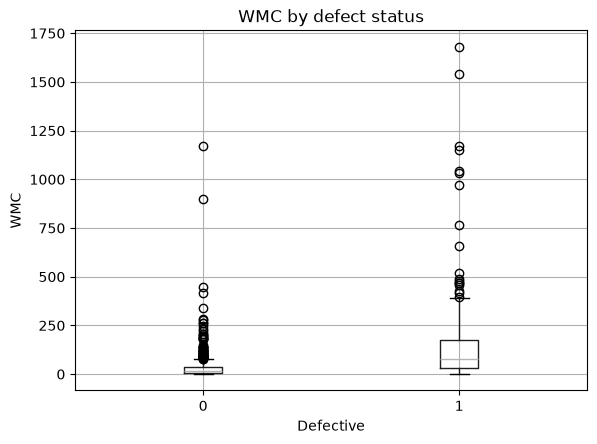

In [36]:
df.boxplot(
    column="wmc",
    by="defective",
)

plt.title("WMC by defect status")
plt.suptitle("")
plt.xlabel("Defective")
plt.ylabel("WMC")
plt.show()

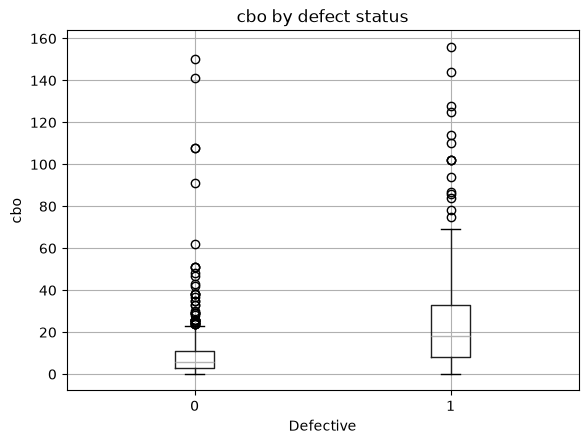

In [37]:
df.boxplot(
    column="cbo",
    by="defective",
)

plt.title("cbo by defect status")
plt.suptitle("")
plt.xlabel("Defective")
plt.ylabel("cbo")
plt.show()

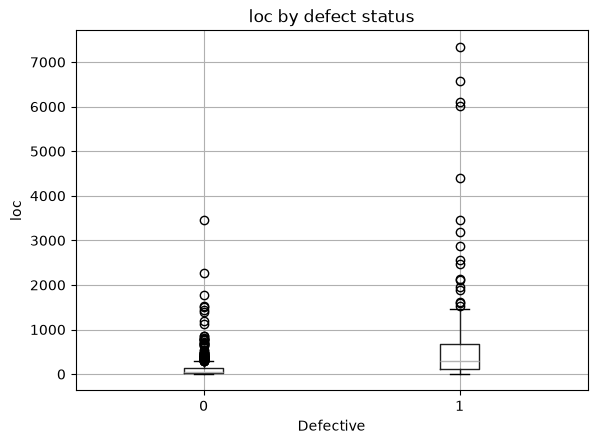

In [39]:
df.boxplot(
    column="numberOfLinesOfCode",
    by="defective",
)

plt.title("loc by defect status")
plt.suptitle("")
plt.xlabel("Defective")
plt.ylabel("loc")
plt.show()

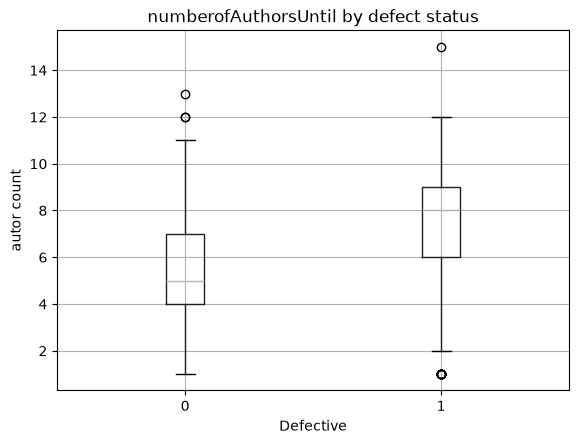

In [41]:
df.boxplot(
    column="numberOfAuthorsUntil",
    by="defective",
)

plt.title("numberofAuthorsUntil by defect status")
plt.suptitle("")
plt.xlabel("Defective")
plt.ylabel("autor count")
plt.show()

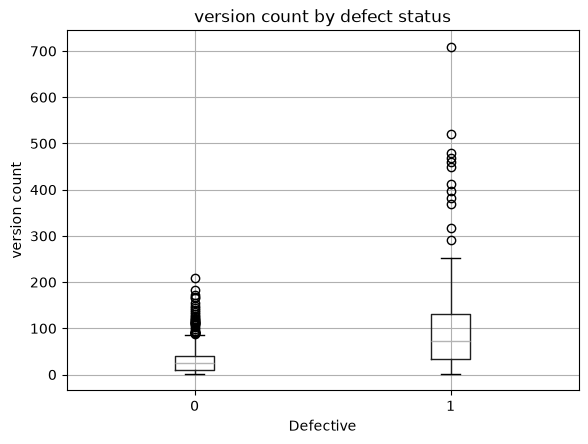

In [43]:
df.boxplot(
    column="numberOfVersionsUntil",
    by="defective",
)

plt.title("version count by defect status")
plt.suptitle("")
plt.xlabel("Defective")
plt.ylabel("version count")
plt.show()

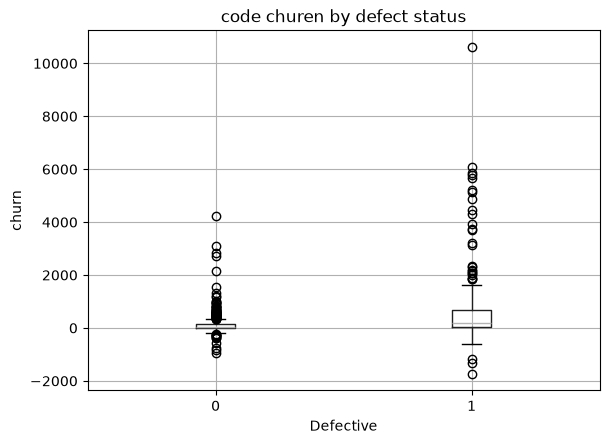

In [44]:
df.boxplot(
    column="codeChurnUntil",
    by="defective",
)

plt.title("code churen by defect status")
plt.suptitle("")
plt.xlabel("Defective")
plt.ylabel("churn")
plt.show()

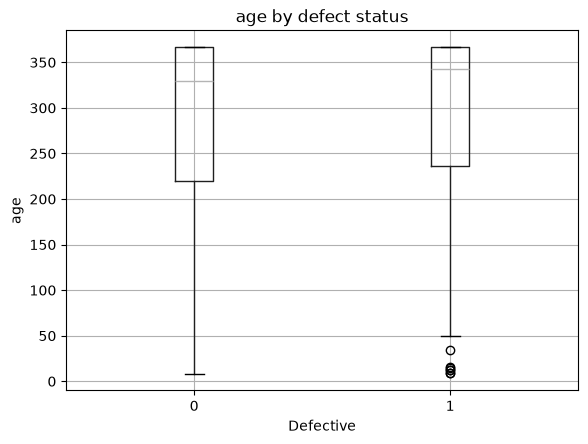

In [45]:
df.boxplot(
    column="ageWithRespectTo",
    by="defective",
)

plt.title("age by defect status")
plt.suptitle("")
plt.xlabel("Defective")
plt.ylabel("age")
plt.show()

In [46]:
numeric = df.select_dtypes(include="number")

In [47]:
corr = numeric.corr(method="spearman")

In [48]:
corr["defective"].sort_values(ascending=False)

defective                      1.000000
bugs                           0.993820
wmc                            0.400412
numberOfLinesOfCode            0.393725
numberOfVersionsUntil          0.382558
linesAddedUntil                0.382547
fanOut                         0.379836
linesRemovedUntil              0.376457
rfc                            0.374448
cbo                            0.361151
maxLinesAddedUntil             0.343831
majorBugs                      0.339148
maxCodeChurnUntil              0.336637
numberOfAuthorsUntil           0.336027
avgLinesAddedUntil             0.329821
maxLinesRemovedUntil           0.329771
avgLinesRemovedUntil           0.327577
numberOfFixesUntil             0.285237
lcom                           0.271904
numberOfMethods                0.271593
numberOfPrivateMethods         0.251623
nonTrivialBugs                 0.250252
codeChurnUntil                 0.250049
numberOfAttributes             0.239533
numberOfPublicAttributes       0.218955


In [49]:
def load_project(project_name):
    data_dir = Path("../data/raw") / project_name

    ck = pd.read_csv(
        data_dir / "single-version-ck-oo.csv",
        sep=";",
    )

    change = pd.read_csv(
        data_dir / "change-metrics.csv",
        sep=";",
    )

    ck = clean_columns(ck)
    change = clean_columns(change)

    # Verify unique observations
    assert not ck["classname"].duplicated().any()
    assert not change["classname"].duplicated().any()

    # Verify the same classes exist in both
    assert set(ck["classname"]) == set(change["classname"])

    # Verify labels agree before dropping duplicates
    label_check = ck[["classname", "bugs"]].merge(
        change[["classname", "bugs"]],
        on="classname",
        suffixes=("_ck", "_change"),
        validate="one_to_one",
    )

    assert (
        label_check["bugs_ck"] ==
        label_check["bugs_change"]
    ).all()

    # Keep labels from CK only
    change_features = change.drop(
        columns=[
            "bugs",
            "nonTrivialBugs",
            "majorBugs",
            "criticalBugs",
            "highPriorityBugs",
        ]
    )

    merged = ck.merge(
        change_features,
        on="classname",
        how="inner",
        validate="one_to_one",
    )

    merged["project"] = project_name
    merged["defective"] = (merged["bugs"] > 0).astype(int)

    return merged

In [50]:
projects = [
    "eclipse",
    "equinox",
    "lucene",
    "mylyn",
    "pde",
]

project_dfs = [
    load_project(project)
    for project in projects
]

all_df = pd.concat(
    project_dfs,
    ignore_index=True,
)

In [51]:
all_df.groupby("project")["defective"].agg(
    observations="size",
    defective="sum",
    defect_rate="mean",
)

,observations,defective,defect_rate
project,,,
eclipse,997,206,0.206620
equinox,324,129,0.398148
lucene,691,64,0.092619
mylyn,1862,245,0.131579
pde,1497,209,0.139613
